Links para o Dataset:

Teste: https://utad4-my.sharepoint.com/:u:/r/personal/al71720_alunos_utad_pt/Documents/DATASETS/test_fold.zip?csf=1&web=1&e=a7PXAn

Treino: https://utad4-my.sharepoint.com/:u:/r/personal/al71720_alunos_utad_pt/Documents/DATASETS/train_folds.zip?csf=1&web=1&e=AI7768

Treino do Grupo1

Epoch 1/25 | Val Acc: 0.2973
Epoch 2/25 | Val Acc: 0.1297
Epoch 3/25 | Val Acc: 0.2378
Epoch 4/25 | Val Acc: 0.4270
Epoch 5/25 | Val Acc: 0.3297
Epoch 6/25 | Val Acc: 0.3568
Epoch 7/25 | Val Acc: 0.3730
Epoch 8/25 | Val Acc: 0.4432
Epoch 9/25 | Val Acc: 0.4541
Epoch 10/25 | Val Acc: 0.4973
Epoch 11/25 | Val Acc: 0.5351
Epoch 12/25 | Val Acc: 0.5459
Epoch 13/25 | Val Acc: 0.5243
Epoch 14/25 | Val Acc: 0.5297
Epoch 15/25 | Val Acc: 0.5027
Epoch 16/25 | Val Acc: 0.5027
Epoch 17/25 | Val Acc: 0.5514
Epoch 18/25 | Val Acc: 0.5351
Epoch 19/25 | Val Acc: 0.5784
Epoch 20/25 | Val Acc: 0.5622
Epoch 21/25 | Val Acc: 0.5514
Epoch 22/25 | Val Acc: 0.5459
Epoch 23/25 | Val Acc: 0.5568
Epoch 24/25 | Val Acc: 0.5730
Epoch 25/25 | Val Acc: 0.5676

Relatório Final:
                         precision    recall  f1-score   support

  Non-syndromic RP_EYS       0.51      0.54      0.53        87
Non-syndromic RP_IMPG2       0.36      0.57      0.44         7
Non-syndromic RP_PDE6B       0.00      0.00    

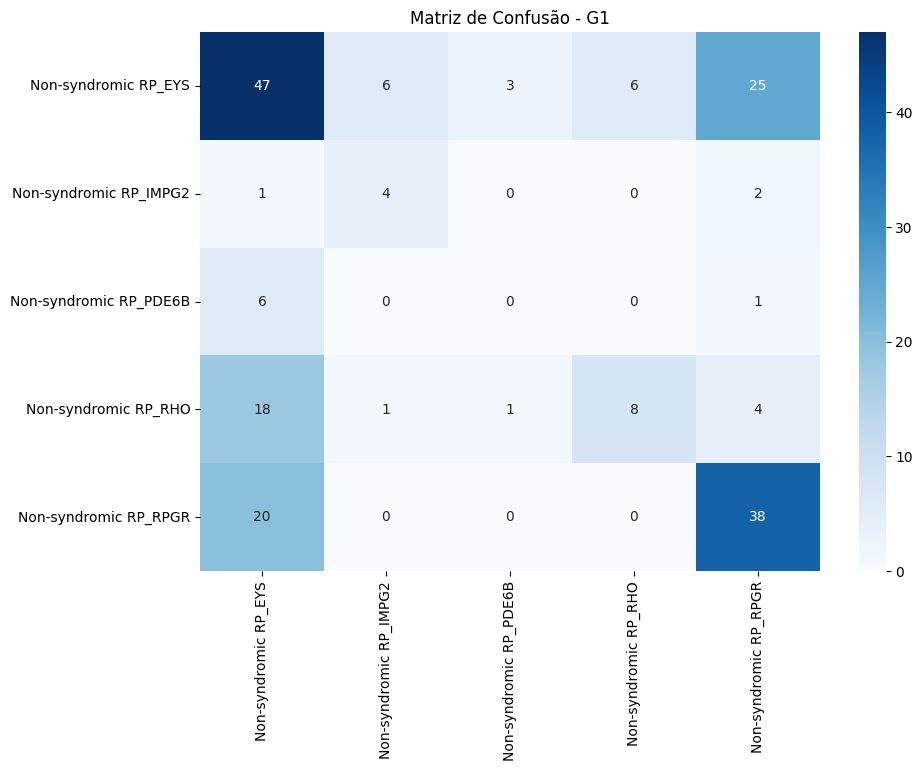

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIGURAÇÕES
# ==========================================
DATA_ROOT = '/content/drive/MyDrive/Dataset'
CURRENT_GROUP = 'G1'
TARGET_GENES = [
    'Non-syndromic RP_EYS',
    'Non-syndromic RP_RPGR',
    'Non-syndromic RP_RHO',
    'Non-syndromic RP_PDE6B',
    'Non-syndromic RP_IMPG2'
]

BATCH_SIZE = 32
LEARNING_RATE_FC = 0.001    # LR mais alta para a nova camada
LEARNING_RATE_FT = 0.00001  # LR muito baixa para as camadas descongeladas (Fine-tuning)
EPOCHS = 25
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. DATASET (Mantendo a tua estrutura de Folds)
# ==========================================
class RP_Complex_Dataset(Dataset):
    def __init__(self, root_dir, group_name, genes_list, mode='train', transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(genes_list)
        self.class_to_idx = {gene: i for i, gene in enumerate(self.classes)}

        base_folder = 'train_folds' if mode in ['train', 'val'] else 'test_fold'
        group_path = os.path.join(root_dir, base_folder, group_name)

        for gene in genes_list:
            gene_path = os.path.join(group_path, gene)
            if not os.path.exists(gene_path): continue
            label_idx = self.class_to_idx[gene]

            if mode in ['train', 'val']:
                target_nums = ['1', '2', '3', '4'] if mode == 'train' else ['5']
                for folder_name in os.listdir(gene_path):
                    full_fold_path = os.path.join(gene_path, folder_name)
                    if os.path.isdir(full_fold_path) and "fold" in folder_name.lower():
                        if any(num in folder_name for num in target_nums):
                            files = [f for f in os.listdir(full_fold_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                            for f in files:
                                self.image_paths.append(os.path.join(full_fold_path, f))
                                self.labels.append(label_idx)
            else:
                files = [f for f in os.listdir(gene_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                for f in files:
                    self.image_paths.append(os.path.join(gene_path, f))
                    self.labels.append(label_idx)

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# ==========================================
# 3. PREPARAÇÃO
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='train', transform=train_tf)
val_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='val', transform=eval_tf)
test_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='test', transform=eval_tf)

# Cálculo de pesos para a Loss Function (Balanceamento)
counts = np.bincount(train_ds.labels)
weights = torch.tensor([1.0 / c for c in counts], dtype=torch.float).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODELO COM FINE-TUNING
# ==========================================
model = models.resnet50(weights='IMAGENET1K_V1')

# Congelar tudo inicialmente
for param in model.parameters():
    param.requires_grad = False

# Descongelar a camada 4 (as últimas camadas convolucionais)
for param in model.layer4.parameters():
    param.requires_grad = True

# Nova camada de classificação
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(TARGET_GENES))
)
model = model.to(DEVICE)

# Otimizador com taxas de aprendizagem diferentes (Diferencial Learning Rate)
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': LEARNING_RATE_FT},
    {'params': model.fc.parameters(), 'lr': LEARNING_RATE_FC}
])

criterion = nn.CrossEntropyLoss(weight=weights)

# ==========================================
# 5. LOOP DE TREINO E AVALIAÇÃO
# ==========================================
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()

    # Validação rápida
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            _, pred = torch.max(model(inputs), 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), f'melhor_modelo_{CURRENT_GROUP}.pth')

# --- AVALIAÇÃO FINAL ---
model.load_state_dict(torch.load(f'melhor_modelo_{CURRENT_GROUP}.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        _, pred = torch.max(model(inputs.to(DEVICE)), 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nRelatório Final:\n", classification_report(all_labels, all_preds, target_names=sorted(TARGET_GENES)))

# Matriz de Confusão
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=sorted(TARGET_GENES), yticklabels=sorted(TARGET_GENES), cmap='Blues')
plt.title(f'Matriz de Confusão - {CURRENT_GROUP}')
plt.show()

Treino Grupo 2


--- Iniciando Treino para G2 ---
Época 1/25 | Train Acc: 0.2521 | Val Acc: 0.2500
Época 2/25 | Train Acc: 0.2715 | Val Acc: 0.3295
Época 3/25 | Train Acc: 0.3767 | Val Acc: 0.3182
Época 4/25 | Train Acc: 0.4654 | Val Acc: 0.2955
Época 5/25 | Train Acc: 0.4765 | Val Acc: 0.2159
Época 6/25 | Train Acc: 0.5789 | Val Acc: 0.3295
Época 7/25 | Train Acc: 0.6565 | Val Acc: 0.3409
Época 8/25 | Train Acc: 0.6399 | Val Acc: 0.3864
Época 9/25 | Train Acc: 0.7258 | Val Acc: 0.4091
Época 10/25 | Train Acc: 0.7147 | Val Acc: 0.3636
Época 11/25 | Train Acc: 0.7978 | Val Acc: 0.3750
Época 12/25 | Train Acc: 0.8116 | Val Acc: 0.4205
Época 13/25 | Train Acc: 0.8199 | Val Acc: 0.5000
Época 14/25 | Train Acc: 0.8698 | Val Acc: 0.4205
Época 15/25 | Train Acc: 0.8670 | Val Acc: 0.5909
Época 16/25 | Train Acc: 0.8781 | Val Acc: 0.4205
Época 17/25 | Train Acc: 0.9030 | Val Acc: 0.5227
Época 18/25 | Train Acc: 0.9003 | Val Acc: 0.5227
Época 19/25 | Train Acc: 0.8892 | Val Acc: 0.5568
Época 20/25 | Train Acc: 

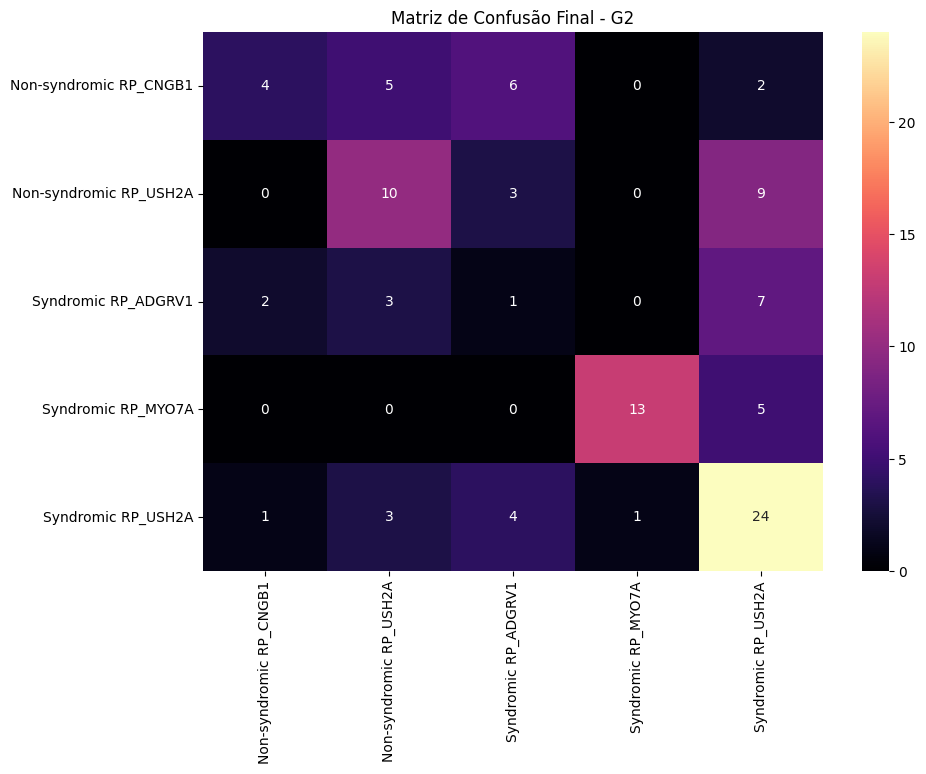

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIGURAÇÕES (GRUPO 2)
# ==========================================
DATA_ROOT = '/content/drive/MyDrive/Dataset'
CURRENT_GROUP = 'G2'


TARGET_GENES = [
    'Syndromic RP_USH2A',
    'Non-syndromic RP_USH2A',
    'Non-syndromic RP_CNGB1',
    'Syndromic RP_MYO7A',
    'Syndromic RP_ADGRV1'
]

BATCH_SIZE = 32
LEARNING_RATE_FC = 0.001    # Camada final
LEARNING_RATE_FT = 0.00001  # Fine-tuning da layer4
EPOCHS = 25
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. DATASET (Folds 1-4 Treino, Fold 5 Val)
# ==========================================
class RP_Complex_Dataset(Dataset):
    def __init__(self, root_dir, group_name, genes_list, mode='train', transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(genes_list)
        self.class_to_idx = {gene: i for i, gene in enumerate(self.classes)}

        base_folder = 'train_folds' if mode in ['train', 'val'] else 'test_fold'
        group_path = os.path.join(root_dir, base_folder, group_name)

        for gene in genes_list:
            gene_path = os.path.join(group_path, gene)
            if not os.path.exists(gene_path): continue
            label_idx = self.class_to_idx[gene]

            if mode in ['train', 'val']:
                target_nums = ['1', '2', '3', '4'] if mode == 'train' else ['5']
                for folder_name in os.listdir(gene_path):
                    full_fold_path = os.path.join(gene_path, folder_name)
                    if os.path.isdir(full_fold_path) and "fold" in folder_name.lower():
                        if any(num in folder_name for num in target_nums):
                            files = [f for f in os.listdir(full_fold_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                            for f in files:
                                self.image_paths.append(os.path.join(full_fold_path, f))
                                self.labels.append(label_idx)
            else:
                files = [f for f in os.listdir(gene_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                for f in files:
                    self.image_paths.append(os.path.join(gene_path, f))
                    self.labels.append(label_idx)

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# ==========================================
# 3. PREPARAÇÃO DOS DATALOADERS
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='train', transform=train_tf)
val_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='val', transform=eval_tf)
test_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='test', transform=eval_tf)

# Pesos para equilibrar a importância dos genes raros no G2
counts = np.bincount(train_ds.labels)
weights = torch.tensor([1.0 / c for c in counts], dtype=torch.float).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODELO (ResNet50 com Layer 4 aberta)
# ==========================================
model = models.resnet50(weights='IMAGENET1K_V1')

for param in model.parameters(): param.requires_grad = False
for param in model.layer4.parameters(): param.requires_grad = True

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(TARGET_GENES))
)
model = model.to(DEVICE)

optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': LEARNING_RATE_FT},
    {'params': model.fc.parameters(), 'lr': LEARNING_RATE_FC}
])
criterion = nn.CrossEntropyLoss(weight=weights)

# ==========================================
# 5. TREINO
# ==========================================
best_val_acc = 0.0
print(f"\n--- Iniciando Treino para {CURRENT_GROUP} ---")

for epoch in range(EPOCHS):
    model.train()
    t_correct, t_total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, pred = torch.max(outputs, 1)
        t_total += labels.size(0)
        t_correct += (pred == labels).sum().item()

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, pred = torch.max(model(inputs.to(DEVICE)), 1)
            v_total += labels.size(0)
            v_correct += (pred == labels.to(DEVICE)).sum().item()

    train_acc = t_correct / t_total
    val_acc = v_correct / v_total
    print(f"Época {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'melhor_modelo_{CURRENT_GROUP}.pth')

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
print(f"\n--- Relatório Final no Test Fold ({CURRENT_GROUP}) ---")
model.load_state_dict(torch.load(f'melhor_modelo_{CURRENT_GROUP}.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        _, pred = torch.max(model(inputs.to(DEVICE)), 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='magma')
plt.title(f'Matriz de Confusão Final - {CURRENT_GROUP}')
plt.show()

Treino Grupo 3


--- Iniciando Ronda 1 (Baseline) para G3 ---
Época 1/25 | Train Acc: 0.2912 | Val Acc: 0.1875
Época 2/25 | Train Acc: 0.4396 | Val Acc: 0.1458
Época 3/25 | Train Acc: 0.6154 | Val Acc: 0.6875
Época 4/25 | Train Acc: 0.8022 | Val Acc: 0.4167
Época 5/25 | Train Acc: 0.7637 | Val Acc: 0.5833
Época 6/25 | Train Acc: 0.8846 | Val Acc: 0.6458
Época 7/25 | Train Acc: 0.8407 | Val Acc: 0.6250
Época 8/25 | Train Acc: 0.9121 | Val Acc: 0.7083
Época 9/25 | Train Acc: 0.9396 | Val Acc: 0.7292
Época 10/25 | Train Acc: 0.9286 | Val Acc: 0.7292
Época 11/25 | Train Acc: 0.9505 | Val Acc: 0.7292
Época 12/25 | Train Acc: 0.9890 | Val Acc: 0.7500
Época 13/25 | Train Acc: 0.9231 | Val Acc: 0.7500
Época 14/25 | Train Acc: 0.9615 | Val Acc: 0.7500
Época 15/25 | Train Acc: 0.9835 | Val Acc: 0.7500
Época 16/25 | Train Acc: 0.9725 | Val Acc: 0.7500
Época 17/25 | Train Acc: 0.9670 | Val Acc: 0.7500
Época 18/25 | Train Acc: 0.9890 | Val Acc: 0.7500
Época 19/25 | Train Acc: 0.9505 | Val Acc: 0.7500
Época 20/25 |

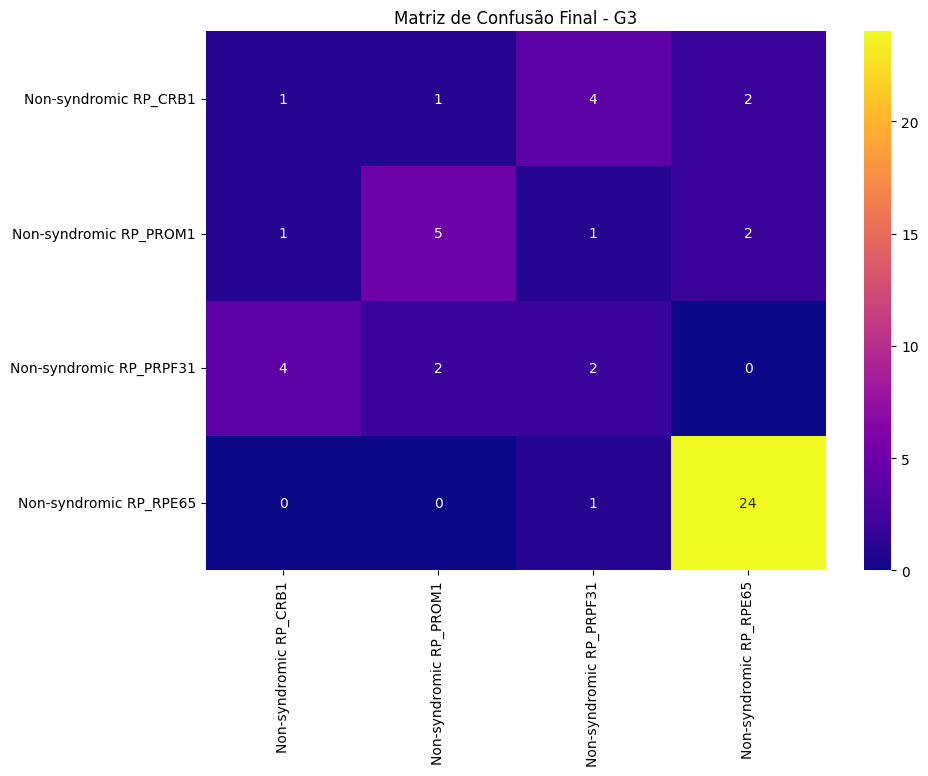

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIGURAÇÕES (GRUPO 3)
# ==========================================
DATA_ROOT = '/content/drive/MyDrive/Dataset'
CURRENT_GROUP = 'G3'

TARGET_GENES = [
    'Non-syndromic RP_RPE65',
    'Non-syndromic RP_PRPF31',
    'Non-syndromic RP_CRB1',
    'Non-syndromic RP_PROM1'
]

BATCH_SIZE = 32
LEARNING_RATE_FC = 0.001    # Cabeça da rede
LEARNING_RATE_FT = 0.00001  # Fine-tuning da layer4
EPOCHS = 25
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. DATASET (Gestão de Folds)
# ==========================================
class RP_Complex_Dataset(Dataset):
    def __init__(self, root_dir, group_name, genes_list, mode='train', transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(genes_list)
        self.class_to_idx = {gene: i for i, gene in enumerate(self.classes)}

        base_folder = 'train_folds' if mode in ['train', 'val'] else 'test_fold'
        group_path = os.path.join(root_dir, base_folder, group_name)

        for gene in genes_list:
            gene_path = os.path.join(group_path, gene)
            if not os.path.exists(gene_path): continue
            label_idx = self.class_to_idx[gene]

            if mode in ['train', 'val']:
                target_nums = ['1', '2', '3', '4'] if mode == 'train' else ['5']
                for folder_name in os.listdir(gene_path):
                    full_fold_path = os.path.join(gene_path, folder_name)
                    if os.path.isdir(full_fold_path) and "fold" in folder_name.lower():
                        if any(num in folder_name for num in target_nums):
                            files = [f for f in os.listdir(full_fold_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                            for f in files:
                                self.image_paths.append(os.path.join(full_fold_path, f))
                                self.labels.append(label_idx)
            else:
                files = [f for f in os.listdir(gene_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                for f in files:
                    self.image_paths.append(os.path.join(gene_path, f))
                    self.labels.append(label_idx)

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# ==========================================
# 3. PREPARAÇÃO DOS DATALOADERS
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='train', transform=train_tf)
val_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='val', transform=eval_tf)
test_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='test', transform=eval_tf)

# Pesos para compensar o desequilíbrio no G3
counts = np.bincount(train_ds.labels)
weights = torch.tensor([1.0 / c for c in counts], dtype=torch.float).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODELO (ResNet50 + Fine-Tuning Layer 4)
# ==========================================
model = models.resnet50(weights='IMAGENET1K_V1')

for param in model.parameters(): param.requires_grad = False
for param in model.layer4.parameters(): param.requires_grad = True

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(TARGET_GENES))
)
model = model.to(DEVICE)

optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': LEARNING_RATE_FT},
    {'params': model.fc.parameters(), 'lr': LEARNING_RATE_FC}
])
criterion = nn.CrossEntropyLoss(weight=weights)

# ==========================================
# 5. TREINO
# ==========================================
best_val_acc = 0.0
print(f"\n--- Iniciando Ronda 1 (Baseline) para {CURRENT_GROUP} ---")

for epoch in range(EPOCHS):
    model.train()
    t_correct, t_total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, pred = torch.max(outputs, 1)
        t_total += labels.size(0)
        t_correct += (pred == labels).sum().item()

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, pred = torch.max(model(inputs.to(DEVICE)), 1)
            v_total += labels.size(0)
            v_correct += (pred == labels.to(DEVICE)).sum().item()

    train_acc = t_correct / t_total
    val_acc = v_correct / v_total
    print(f"Época {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'melhor_modelo_{CURRENT_GROUP}.pth')

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
print(f"\n--- Relatório Final no Test Fold ({CURRENT_GROUP}) ---")
model.load_state_dict(torch.load(f'melhor_modelo_{CURRENT_GROUP}.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        _, pred = torch.max(model(inputs.to(DEVICE)), 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='plasma')
plt.title(f'Matriz de Confusão Final - {CURRENT_GROUP}')
plt.show()

Treino Grupo 4


--- Iniciando Ronda 1 (Baseline) para G4 ---
Época 1/25 | Train Acc: 0.3985 | Val Acc: 0.2258
Época 2/25 | Train Acc: 0.4887 | Val Acc: 0.2258
Época 3/25 | Train Acc: 0.5865 | Val Acc: 0.4516
Época 4/25 | Train Acc: 0.6617 | Val Acc: 0.4516
Época 5/25 | Train Acc: 0.8872 | Val Acc: 0.2903
Época 6/25 | Train Acc: 0.8571 | Val Acc: 0.4194
Época 7/25 | Train Acc: 0.8647 | Val Acc: 0.4516
Época 8/25 | Train Acc: 0.9173 | Val Acc: 0.4839
Época 9/25 | Train Acc: 0.8496 | Val Acc: 0.4194
Época 10/25 | Train Acc: 0.9248 | Val Acc: 0.3548
Época 11/25 | Train Acc: 0.9173 | Val Acc: 0.5161
Época 12/25 | Train Acc: 0.9624 | Val Acc: 0.4839
Época 13/25 | Train Acc: 0.9774 | Val Acc: 0.4839
Época 14/25 | Train Acc: 0.9474 | Val Acc: 0.4516
Época 15/25 | Train Acc: 0.9774 | Val Acc: 0.4839
Época 16/25 | Train Acc: 0.9850 | Val Acc: 0.5484
Época 17/25 | Train Acc: 0.9925 | Val Acc: 0.5484
Época 18/25 | Train Acc: 1.0000 | Val Acc: 0.5161
Época 19/25 | Train Acc: 0.9925 | Val Acc: 0.5484
Época 20/25 |

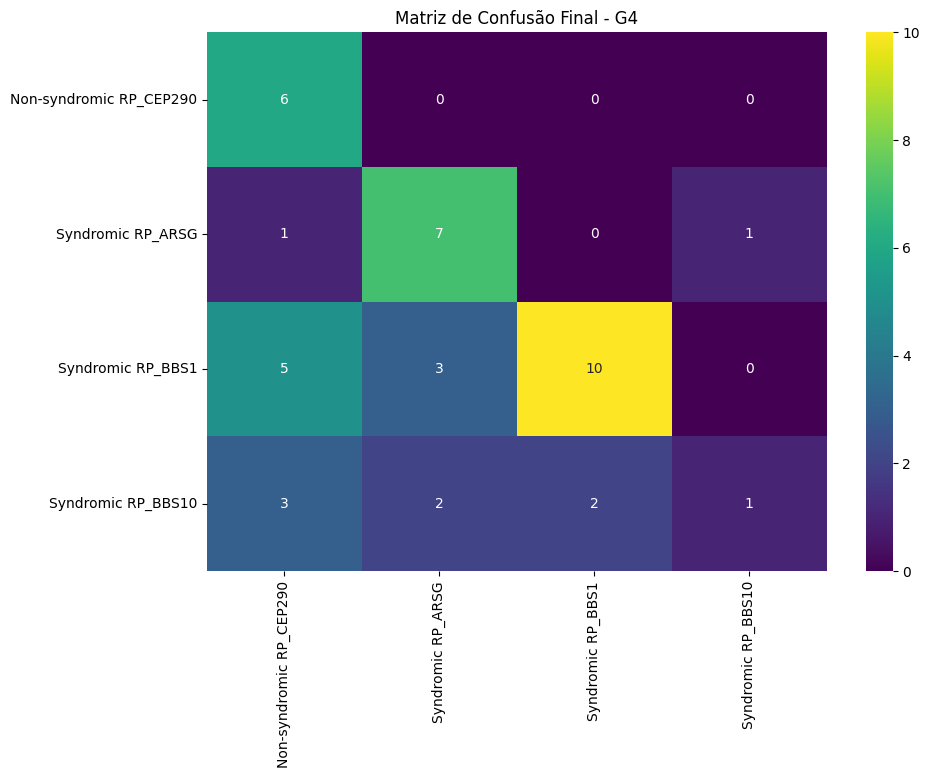

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIGURAÇÕES (GRUPO 4)
# ==========================================
DATA_ROOT = '/content/drive/MyDrive/Dataset'
CURRENT_GROUP = 'G4'

TARGET_GENES = [
    'Syndromic RP_BBS1',
    'Syndromic RP_BBS10',
    'Syndromic RP_ARSG',
    'Non-syndromic RP_CEP290'
]

BATCH_SIZE = 32
LEARNING_RATE_FC = 0.001    # Cabeça da rede
LEARNING_RATE_FT = 0.00001  # Fine-tuning da layer4
EPOCHS = 25
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. DATASET (Folds 1-4 Treino, Fold 5 Val)
# ==========================================
class RP_Complex_Dataset(Dataset):
    def __init__(self, root_dir, group_name, genes_list, mode='train', transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(genes_list)
        self.class_to_idx = {gene: i for i, gene in enumerate(self.classes)}

        base_folder = 'train_folds' if mode in ['train', 'val'] else 'test_fold'
        group_path = os.path.join(root_dir, base_folder, group_name)

        for gene in genes_list:
            gene_path = os.path.join(group_path, gene)
            if not os.path.exists(gene_path): continue
            label_idx = self.class_to_idx[gene]

            if mode in ['train', 'val']:
                target_nums = ['1', '2', '3', '4'] if mode == 'train' else ['5']
                for folder_name in os.listdir(gene_path):
                    full_fold_path = os.path.join(gene_path, folder_name)
                    if os.path.isdir(full_fold_path) and "fold" in folder_name.lower():
                        if any(num in folder_name for num in target_nums):
                            files = [f for f in os.listdir(full_fold_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                            for f in files:
                                self.image_paths.append(os.path.join(full_fold_path, f))
                                self.labels.append(label_idx)
            else:
                files = [f for f in os.listdir(gene_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                for f in files:
                    self.image_paths.append(os.path.join(gene_path, f))
                    self.labels.append(label_idx)

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# ==========================================
# 3. PREPARAÇÃO DOS DATALOADERS
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='train', transform=train_tf)
val_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='val', transform=eval_tf)
test_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='test', transform=eval_tf)

counts = np.bincount(train_ds.labels)
weights = torch.tensor([1.0 / c for c in counts], dtype=torch.float).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODELO (ResNet50 + Fine-Tuning Layer 4)
# ==========================================
model = models.resnet50(weights='IMAGENET1K_V1')

for param in model.parameters(): param.requires_grad = False
for param in model.layer4.parameters(): param.requires_grad = True

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(TARGET_GENES))
)
model = model.to(DEVICE)

optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': LEARNING_RATE_FT},
    {'params': model.fc.parameters(), 'lr': LEARNING_RATE_FC}
])
criterion = nn.CrossEntropyLoss(weight=weights)

# ==========================================
# 5. TREINO
# ==========================================
best_val_acc = 0.0
print(f"\n--- Iniciando Ronda 1 (Baseline) para {CURRENT_GROUP} ---")

for epoch in range(EPOCHS):
    model.train()
    t_correct, t_total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, pred = torch.max(outputs, 1)
        t_total += labels.size(0)
        t_correct += (pred == labels).sum().item()

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, pred = torch.max(model(inputs.to(DEVICE)), 1)
            v_total += labels.size(0)
            v_correct += (pred == labels.to(DEVICE)).sum().item()

    train_acc = t_correct / t_total
    val_acc = v_correct / v_total
    print(f"Época {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'melhor_modelo_{CURRENT_GROUP}.pth')

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
print(f"\n--- Relatório Final no Test Fold ({CURRENT_GROUP}) ---")
model.load_state_dict(torch.load(f'melhor_modelo_{CURRENT_GROUP}.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        _, pred = torch.max(model(inputs.to(DEVICE)), 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='viridis')
plt.title(f'Matriz de Confusão Final - {CURRENT_GROUP}')
plt.show()

Treino Grupo 5


--- Iniciando Ronda 1 (Baseline) para G5 ---
Época 1/25 | Train Acc: 0.2812 | Val Acc: 0.5789
Época 2/25 | Train Acc: 0.2812 | Val Acc: 0.4211
Época 3/25 | Train Acc: 0.5417 | Val Acc: 0.4211
Época 4/25 | Train Acc: 0.7083 | Val Acc: 0.7368
Época 5/25 | Train Acc: 0.7188 | Val Acc: 0.6316
Época 6/25 | Train Acc: 0.7812 | Val Acc: 0.3158
Época 7/25 | Train Acc: 0.8021 | Val Acc: 0.7895
Época 8/25 | Train Acc: 0.8646 | Val Acc: 0.6842
Época 9/25 | Train Acc: 0.8958 | Val Acc: 0.5263
Época 10/25 | Train Acc: 0.9583 | Val Acc: 0.6316
Época 11/25 | Train Acc: 0.8958 | Val Acc: 0.7895
Época 12/25 | Train Acc: 0.9375 | Val Acc: 0.5789
Época 13/25 | Train Acc: 0.9271 | Val Acc: 0.8947
Época 14/25 | Train Acc: 0.9583 | Val Acc: 0.8947
Época 15/25 | Train Acc: 0.9479 | Val Acc: 0.7368
Época 16/25 | Train Acc: 0.9792 | Val Acc: 0.7368
Época 17/25 | Train Acc: 0.9583 | Val Acc: 0.7368
Época 18/25 | Train Acc: 0.9792 | Val Acc: 0.8947
Época 19/25 | Train Acc: 0.9792 | Val Acc: 0.8421
Época 20/25 |

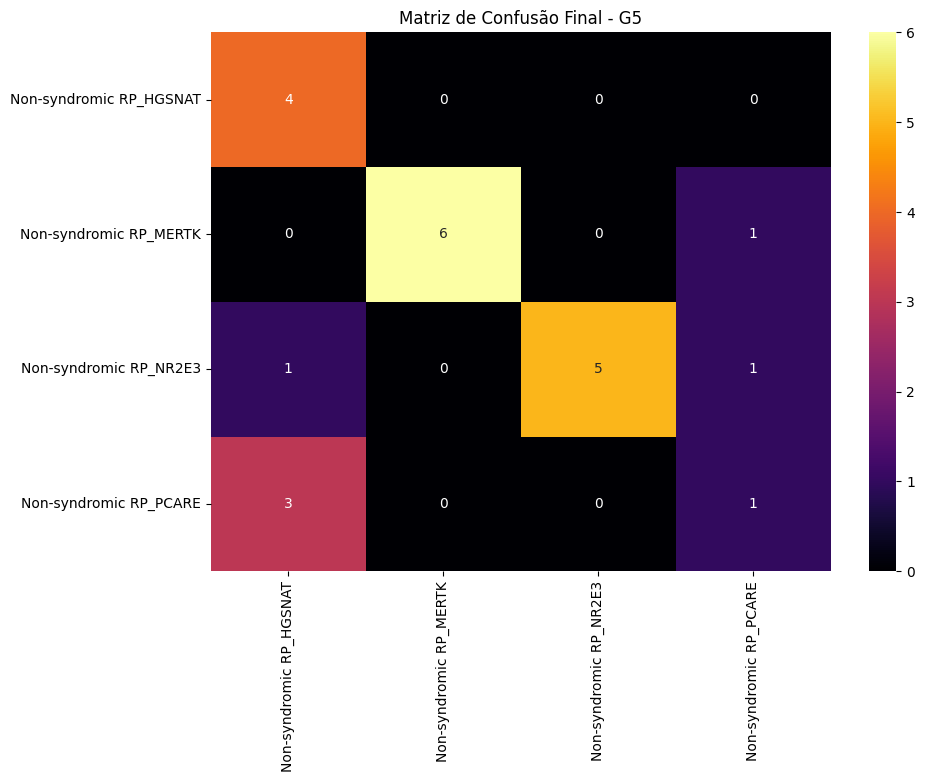

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIGURAÇÕES (GRUPO 5)
# ==========================================
DATA_ROOT = '/content/drive/MyDrive/Dataset'
CURRENT_GROUP = 'G5'


TARGET_GENES = [
    'Non-syndromic RP_NR2E3',
    'Non-syndromic RP_PCARE',
    'Non-syndromic RP_MERTK',
    'Non-syndromic RP_HGSNAT'
]

BATCH_SIZE = 32
LEARNING_RATE_FC = 0.001    # Cabeça da rede (camadas novas)
LEARNING_RATE_FT = 0.00001  # Fine-tuning da layer4 (camadas pré-treinadas)
EPOCHS = 25
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. DATASET (Folds 1-4 Treino, Fold 5 Val)
# ==========================================
class RP_Complex_Dataset(Dataset):
    def __init__(self, root_dir, group_name, genes_list, mode='train', transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(genes_list)
        self.class_to_idx = {gene: i for i, gene in enumerate(self.classes)}

        base_folder = 'train_folds' if mode in ['train', 'val'] else 'test_fold'
        group_path = os.path.join(root_dir, base_folder, group_name)

        for gene in genes_list:
            gene_path = os.path.join(group_path, gene)
            if not os.path.exists(gene_path): continue
            label_idx = self.class_to_idx[gene]

            if mode in ['train', 'val']:
                target_nums = ['1', '2', '3', '4'] if mode == 'train' else ['5']
                for folder_name in os.listdir(gene_path):
                    full_fold_path = os.path.join(gene_path, folder_name)
                    if os.path.isdir(full_fold_path) and "fold" in folder_name.lower():
                        if any(num in folder_name for num in target_nums):
                            files = [f for f in os.listdir(full_fold_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                            for f in files:
                                self.image_paths.append(os.path.join(full_fold_path, f))
                                self.labels.append(label_idx)
            else:
                files = [f for f in os.listdir(gene_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                for f in files:
                    self.image_paths.append(os.path.join(gene_path, f))
                    self.labels.append(label_idx)

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# ==========================================
# 3. PREPARAÇÃO DOS DATALOADERS
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='train', transform=train_tf)
val_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='val', transform=eval_tf)
test_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='test', transform=eval_tf)

# Pesos para equilibrar a Loss (importante no G5 devido à escassez de dados)
counts = np.bincount(train_ds.labels)
weights = torch.tensor([1.0 / c for c in counts], dtype=torch.float).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=min(BATCH_SIZE, len(train_ds)), shuffle=True)
val_loader = DataLoader(val_ds, batch_size=min(BATCH_SIZE, len(val_ds)), shuffle=False)
test_loader = DataLoader(test_ds, batch_size=min(BATCH_SIZE, len(test_ds)), shuffle=False)

# ==========================================
# 4. MODELO (ResNet50 + Fine-Tuning Layer 4)
# ==========================================
model = models.resnet50(weights='IMAGENET1K_V1')

for param in model.parameters(): param.requires_grad = False
for param in model.layer4.parameters(): param.requires_grad = True

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(TARGET_GENES))
)
model = model.to(DEVICE)

optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': LEARNING_RATE_FT},
    {'params': model.fc.parameters(), 'lr': LEARNING_RATE_FC}
])
criterion = nn.CrossEntropyLoss(weight=weights)

# ==========================================
# 5. TREINO
# ==========================================
best_val_acc = 0.0
print(f"\n--- Iniciando Ronda 1 (Baseline) para {CURRENT_GROUP} ---")

for epoch in range(EPOCHS):
    model.train()
    t_correct, t_total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, pred = torch.max(outputs, 1)
        t_total += labels.size(0)
        t_correct += (pred == labels).sum().item()

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, pred = torch.max(model(inputs.to(DEVICE)), 1)
            v_total += labels.size(0)
            v_correct += (pred == labels.to(DEVICE)).sum().item()

    train_acc = t_correct / t_total
    val_acc = v_correct / v_total
    print(f"Época {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'melhor_modelo_{CURRENT_GROUP}.pth')

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
print(f"\n--- Relatório Final no Test Fold ({CURRENT_GROUP}) ---")
model.load_state_dict(torch.load(f'melhor_modelo_{CURRENT_GROUP}.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        _, pred = torch.max(model(inputs.to(DEVICE)), 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='inferno')
plt.title(f'Matriz de Confusão Final - {CURRENT_GROUP}')
plt.show()

Otimização Do Grupo 1


--- Iniciando Ronda 2 (Otimizada) para G1 ---
Época 1/50 | Train Acc: 0.2207 | Val Acc: 0.0216 | LR: 0.001000
Época 2/50 | Train Acc: 0.2382 | Val Acc: 0.1459 | LR: 0.001000
Época 3/50 | Train Acc: 0.2934 | Val Acc: 0.1946 | LR: 0.001000
Época 4/50 | Train Acc: 0.3230 | Val Acc: 0.1027 | LR: 0.001000
Época 5/50 | Train Acc: 0.3257 | Val Acc: 0.1730 | LR: 0.001000
Época 6/50 | Train Acc: 0.3647 | Val Acc: 0.2703 | LR: 0.001000
Época 7/50 | Train Acc: 0.3943 | Val Acc: 0.2162 | LR: 0.001000
Época 8/50 | Train Acc: 0.4590 | Val Acc: 0.2486 | LR: 0.001000
Época 9/50 | Train Acc: 0.5007 | Val Acc: 0.3027 | LR: 0.001000
Época 10/50 | Train Acc: 0.5370 | Val Acc: 0.2811 | LR: 0.001000
Época 11/50 | Train Acc: 0.4495 | Val Acc: 0.2757 | LR: 0.001000
Época 12/50 | Train Acc: 0.5370 | Val Acc: 0.3081 | LR: 0.001000
Época 13/50 | Train Acc: 0.6057 | Val Acc: 0.3189 | LR: 0.001000
Época 14/50 | Train Acc: 0.6272 | Val Acc: 0.3189 | LR: 0.001000
Época 15/50 | Train Acc: 0.6783 | Val Acc: 0.4108 | 

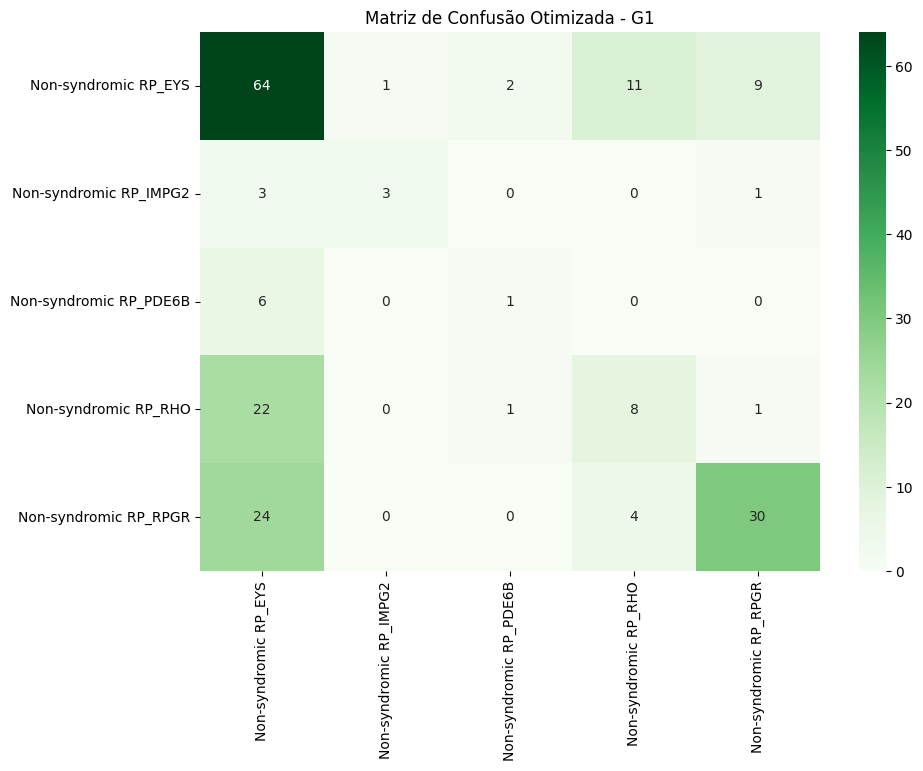

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# ==========================================
# 1. CONFIGURAÇÕES (RONDA 2 - OTIMIZADA)
# ==========================================
DATA_ROOT = '/content/drive/MyDrive/Dataset'
CURRENT_GROUP = 'G1'
TARGET_GENES = [
    'Non-syndromic RP_EYS',
    'Non-syndromic RP_RPGR',
    'Non-syndromic RP_RHO',
    'Non-syndromic RP_PDE6B',
    'Non-syndromic RP_IMPG2'
]

BATCH_SIZE = 32
LEARNING_RATE_FC = 0.001
LEARNING_RATE_FT = 0.00001
EPOCHS = 50
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. DATASET
# ==========================================
class RP_Complex_Dataset(Dataset):
    def __init__(self, root_dir, group_name, genes_list, mode='train', transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(genes_list)
        self.class_to_idx = {gene: i for i, gene in enumerate(self.classes)}

        base_folder = 'train_folds' if mode in ['train', 'val'] else 'test_fold'
        group_path = os.path.join(root_dir, base_folder, group_name)

        for gene in genes_list:
            gene_path = os.path.join(group_path, gene)
            if not os.path.exists(gene_path): continue
            label_idx = self.class_to_idx[gene]

            if mode in ['train', 'val']:
                target_nums = ['1', '2', '3', '4'] if mode == 'train' else ['5']
                for folder_name in os.listdir(gene_path):
                    full_fold_path = os.path.join(gene_path, folder_name)
                    if os.path.isdir(full_fold_path) and "fold" in folder_name.lower():
                        if any(num in folder_name for num in target_nums):
                            files = [f for f in os.listdir(full_fold_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                            for f in files:
                                self.image_paths.append(os.path.join(full_fold_path, f))
                                self.labels.append(label_idx)
            else:
                files = [f for f in os.listdir(gene_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                for f in files:
                    self.image_paths.append(os.path.join(gene_path, f))
                    self.labels.append(label_idx)

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# ==========================================
# 3. PREPARAÇÃO (Data Augmentation Reforçado)
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='train', transform=train_tf)
val_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='val', transform=eval_tf)
test_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='test', transform=eval_tf)

counts = np.bincount(train_ds.labels)
weights = torch.tensor([1.0 / c for c in counts], dtype=torch.float).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODELO (ResNet50 + Regularização Superior)
# ==========================================
model = models.resnet50(weights='IMAGENET1K_V1')
for param in model.parameters(): param.requires_grad = False
for param in model.layer4.parameters(): param.requires_grad = True

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(512, len(TARGET_GENES))
)
model = model.to(DEVICE)

optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': LEARNING_RATE_FT},
    {'params': model.fc.parameters(), 'lr': LEARNING_RATE_FC}
], weight_decay=1e-4)

# Label Smoothing ajuda o modelo a ser menos "teimoso" e a generalizar melhor
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

# Scheduler corrigido (sem o argumento verbose)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

# ==========================================
# 5. TREINO COM EARLY STOPPING
# ==========================================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience = 7
counter = 0

print(f"\n--- Iniciando Ronda 2 (Otimizada) para {CURRENT_GROUP} ---")

for epoch in range(EPOCHS):
    model.train()
    t_correct, t_total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, pred = torch.max(outputs, 1)
        t_total += labels.size(0)
        t_correct += (pred == labels).sum().item()

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, pred = torch.max(model(inputs.to(DEVICE)), 1)
            v_total += labels.size(0)
            v_correct += (pred == labels.to(DEVICE)).sum().item()

    val_acc = v_correct / v_total
    train_acc = t_correct / t_total

    # Obter a Learning Rate atual para o print
    current_lr = optimizer.param_groups[-1]['lr']

    print(f"Época {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")

    # Atualiza o Scheduler
    scheduler.step(val_acc)

    # Lógica de Early Stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, f'melhor_modelo_otimizado_{CURRENT_GROUP}.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"\n[INFO] Early stopping at epoch {epoch+1}. Generalização máxima atingida.")
            break

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
print(f"\n--- Relatório Final Otimizado ({CURRENT_GROUP}) ---")
model.load_state_dict(torch.load(f'melhor_modelo_otimizado_{CURRENT_GROUP}.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        _, pred = torch.max(model(inputs.to(DEVICE)), 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='Greens')
plt.title(f'Matriz de Confusão Otimizada - {CURRENT_GROUP}')
plt.show()

Otimizaçao Grupo 2


--- Iniciando Última Tentativa G2: Congelamento Backbone ---
Época 1/50 | Train Acc: 0.2521 | Val Acc: 0.3068
Época 2/50 | Train Acc: 0.2493 | Val Acc: 0.1932
Época 3/50 | Train Acc: 0.3767 | Val Acc: 0.2727
Época 4/50 | Train Acc: 0.3850 | Val Acc: 0.3409
Época 5/50 | Train Acc: 0.4792 | Val Acc: 0.3409
Época 6/50 | Train Acc: 0.4848 | Val Acc: 0.3523
Época 7/50 | Train Acc: 0.5014 | Val Acc: 0.3636
Época 8/50 | Train Acc: 0.5014 | Val Acc: 0.2727
Época 9/50 | Train Acc: 0.5374 | Val Acc: 0.3636
Época 10/50 | Train Acc: 0.5180 | Val Acc: 0.2159
Época 11/50 | Train Acc: 0.6205 | Val Acc: 0.2045
Época 12/50 | Train Acc: 0.5679 | Val Acc: 0.3750
Época 13/50 | Train Acc: 0.5706 | Val Acc: 0.2841
Época 14/50 | Train Acc: 0.5429 | Val Acc: 0.3977
Época 15/50 | Train Acc: 0.5263 | Val Acc: 0.3409
Época 16/50 | Train Acc: 0.6288 | Val Acc: 0.3523
Época 17/50 | Train Acc: 0.6177 | Val Acc: 0.3750
Época 18/50 | Train Acc: 0.6925 | Val Acc: 0.3977
Época 19/50 | Train Acc: 0.6593 | Val Acc: 0.37

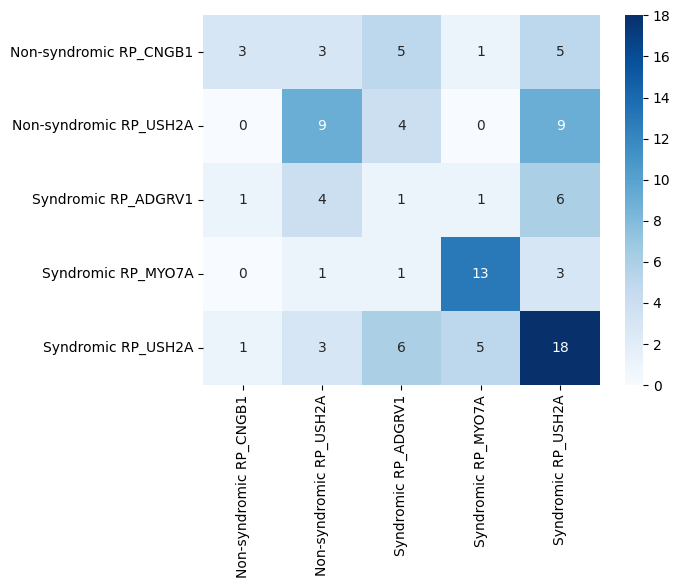

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# ==========================================
# 1. CONFIGURAÇÕES - G2 (OPÇÃO A)
# ==========================================
DATA_ROOT = '/content/drive/MyDrive/Dataset'
CURRENT_GROUP = 'G2'
TARGET_GENES = [
    'Syndromic RP_USH2A',
    'Non-syndromic RP_USH2A',
    'Non-syndromic RP_CNGB1',
    'Syndromic RP_MYO7A',
    'Syndromic RP_ADGRV1'
]

BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 50
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. DATASET
# ==========================================
class RP_Complex_Dataset(Dataset):
    def __init__(self, root_dir, group_name, genes_list, mode='train', transform=None):
        self.transform = transform
        self.image_paths, self.labels = [], []
        self.classes = sorted(genes_list)
        self.class_to_idx = {gene: i for i, gene in enumerate(self.classes)}
        base_folder = 'train_folds' if mode in ['train', 'val'] else 'test_fold'
        group_path = os.path.join(root_dir, base_folder, group_name)
        for gene in genes_list:
            gene_path = os.path.join(group_path, gene)
            if not os.path.exists(gene_path): continue
            label_idx = self.class_to_idx[gene]
            if mode in ['train', 'val']:
                target_nums = ['1', '2', '3', '4'] if mode == 'train' else ['5']
                for folder_name in os.listdir(gene_path):
                    full_fold_path = os.path.join(gene_path, folder_name)
                    if os.path.isdir(full_fold_path) and "fold" in folder_name.lower():
                        if any(num in folder_name for num in target_nums):
                            files = [f for f in os.listdir(full_fold_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                            for f in files:
                                self.image_paths.append(os.path.join(full_fold_path, f))
                                self.labels.append(label_idx)
            else:
                files = [f for f in os.listdir(gene_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                for f in files:
                    self.image_paths.append(os.path.join(gene_path, f))
                    self.labels.append(label_idx)
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# ==========================================
# 3. PREPARAÇÃO
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='train', transform=train_tf)
val_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='val', transform=eval_tf)
test_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='test', transform=eval_tf)

counts = np.bincount(train_ds.labels, minlength=len(TARGET_GENES))
weights = torch.tensor([1.0 / c if c > 0 else 0.0 for c in counts], dtype=torch.float).to(DEVICE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODELO (CONGELAMENTO TOTAL)
# ==========================================
model = models.resnet50(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, len(TARGET_GENES))
)
model = model.to(DEVICE)

optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=weights)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=6)

# ==========================================
# 5. TREINO
# ==========================================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience, counter = 12, 0

print(f"\n--- Iniciando Última Tentativa G2: Congelamento Backbone ---")
for epoch in range(EPOCHS):
    model.train()
    t_correct, t_total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        _, pred = torch.max(outputs, 1)
        t_total += labels.size(0); t_correct += (pred == labels).sum().item()

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, pred = torch.max(model(inputs.to(DEVICE)), 1); v_total += labels.size(0); v_correct += (pred == labels.to(DEVICE)).sum().item()

    val_acc = v_correct / v_total
    print(f"Época {epoch+1}/{EPOCHS} | Train Acc: {t_correct/t_total:.4f} | Val Acc: {val_acc:.4f}")
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, f'melhor_modelo_G2_congelado_final.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"[INFO] Paragem. Modelo estabilizado."); break

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
print("\n--- Relatório Final Opção A (G2) ---")
model.load_state_dict(torch.load(f'melhor_modelo_G2_congelado_final.pth'))
model.eval(); all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        _, pred = torch.max(model(inputs.to(DEVICE)), 1); all_preds.extend(pred.cpu().numpy()); all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes, labels=range(len(TARGET_GENES)), zero_division=0))
sns.heatmap(confusion_matrix(all_labels, all_preds, labels=range(len(TARGET_GENES))), annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='Blues'); plt.show()

Otimização Grupo 3

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]



--- Iniciando Opção A: Congelamento Backbone (G3) ---
Época 1/50 | Train Acc: 0.2802 | Val Acc: 0.6042
Época 2/50 | Train Acc: 0.5824 | Val Acc: 0.2708
Época 3/50 | Train Acc: 0.6429 | Val Acc: 0.3542
Época 4/50 | Train Acc: 0.7473 | Val Acc: 0.5625
Época 5/50 | Train Acc: 0.7912 | Val Acc: 0.5625
Época 6/50 | Train Acc: 0.7418 | Val Acc: 0.6458
Época 7/50 | Train Acc: 0.8132 | Val Acc: 0.5625
Época 8/50 | Train Acc: 0.8571 | Val Acc: 0.7083
Época 9/50 | Train Acc: 0.8297 | Val Acc: 0.7292
Época 10/50 | Train Acc: 0.8736 | Val Acc: 0.7083
Época 11/50 | Train Acc: 0.9286 | Val Acc: 0.7292
Época 12/50 | Train Acc: 0.6868 | Val Acc: 0.7083
Época 13/50 | Train Acc: 0.8791 | Val Acc: 0.6458
Época 14/50 | Train Acc: 0.8462 | Val Acc: 0.7500
Época 15/50 | Train Acc: 0.8956 | Val Acc: 0.7292
Época 16/50 | Train Acc: 0.8462 | Val Acc: 0.7500
Época 17/50 | Train Acc: 0.9451 | Val Acc: 0.7500
Época 18/50 | Train Acc: 0.9286 | Val Acc: 0.7083
Época 19/50 | Train Acc: 0.9066 | Val Acc: 0.7083
Époc

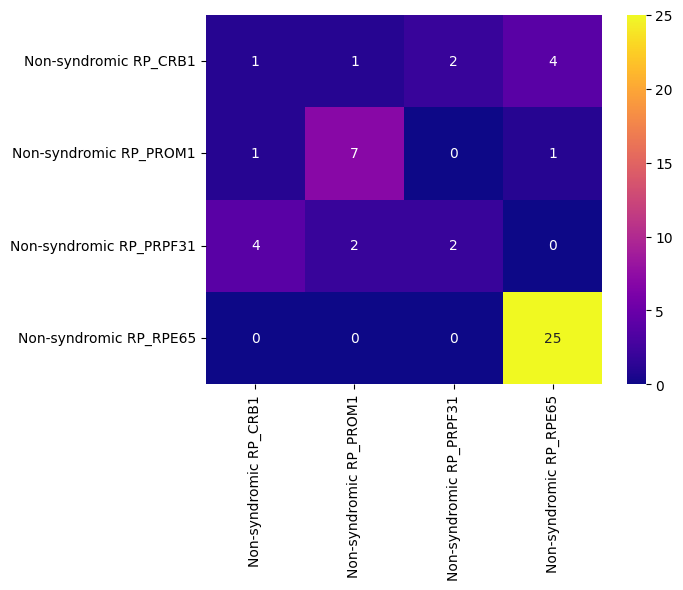

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# ==========================================
# 1. CONFIGURAÇÕES - G3 CONGELAMENTO TOTAL
# ==========================================
DATA_ROOT = '/content/drive/MyDrive/Dataset'
CURRENT_GROUP = 'G3'
TARGET_GENES = [
    'Non-syndromic RP_RPE65',
    'Non-syndromic RP_PRPF31',
    'Non-syndromic RP_CRB1',
    'Non-syndromic RP_PROM1'
]

BATCH_SIZE = 32
LEARNING_RATE = 0.001 # Apenas uma LR, pois só treinamos a cabeça da rede
EPOCHS = 50
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. DATASET
# ==========================================
class RP_Complex_Dataset(Dataset):
    def __init__(self, root_dir, group_name, genes_list, mode='train', transform=None):
        self.transform = transform
        self.image_paths, self.labels = [], []
        self.classes = sorted(genes_list)
        self.class_to_idx = {gene: i for i, gene in enumerate(self.classes)}
        base_folder = 'train_folds' if mode in ['train', 'val'] else 'test_fold'
        group_path = os.path.join(root_dir, base_folder, group_name)

        for gene in genes_list:
            gene_path = os.path.join(group_path, gene)
            if not os.path.exists(gene_path): continue
            label_idx = self.class_to_idx[gene]

            if mode in ['train', 'val']:
                target_nums = ['1', '2', '3', '4'] if mode == 'train' else ['5']
                for folder_name in os.listdir(gene_path):
                    full_fold_path = os.path.join(gene_path, folder_name)
                    if os.path.isdir(full_fold_path) and "fold" in folder_name.lower():
                        if any(num in folder_name for num in target_nums):
                            files = [f for f in os.listdir(full_fold_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                            for f in files:
                                self.image_paths.append(os.path.join(full_fold_path, f))
                                self.labels.append(label_idx)
            else:
                files = [f for f in os.listdir(gene_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                for f in files:
                    self.image_paths.append(os.path.join(gene_path, f))
                    self.labels.append(label_idx)
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# ==========================================
# 3. PREPARAÇÃO (Augmentation Moderado)
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='train', transform=train_tf)
val_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='val', transform=eval_tf)
test_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='test', transform=eval_tf)

counts = np.bincount(train_ds.labels, minlength=len(TARGET_GENES))
weights = torch.tensor([1.0 / c if c > 0 else 0.0 for c in counts], dtype=torch.float).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODELO (CONGELAMENTO TOTAL)
# ==========================================
model = models.resnet50(weights='IMAGENET1K_V1')

# BLOQUEIO: Congelamos todos os parâmetros da rede
for param in model.parameters():
    param.requires_grad = False

# RECONSTRUÇÃO: Apenas a camada final será treinável
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, len(TARGET_GENES))
)
model = model.to(DEVICE)

# IMPORTANTE: Passamos apenas os parâmetros da fc para o otimizador
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss(weight=weights)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)

# ==========================================
# 5. TREINO
# ==========================================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience, counter = 12, 0

print(f"\n--- Iniciando Opção A: Congelamento Backbone (G3) ---")
for epoch in range(EPOCHS):
    model.train()
    t_correct, t_total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, pred = torch.max(outputs, 1)
        t_total += labels.size(0); t_correct += (pred == labels).sum().item()

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, pred = torch.max(model(inputs.to(DEVICE)), 1); v_total += labels.size(0); v_correct += (pred == labels.to(DEVICE)).sum().item()

    val_acc = v_correct / v_total
    train_acc = t_correct / t_total
    print(f"Época {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, f'melhor_modelo_G3_congelado.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"[INFO] Paragem. Modelo estabilizado sem memorização excessiva."); break

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
print("\n--- Relatório Final Opção A (G3) ---")
model.load_state_dict(torch.load(f'melhor_modelo_G3_congelado.pth'))
model.eval(); all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        _, pred = torch.max(model(inputs.to(DEVICE)), 1); all_preds.extend(pred.cpu().numpy()); all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes, labels=range(len(TARGET_GENES)), zero_division=0))
sns.heatmap(confusion_matrix(all_labels, all_preds, labels=range(len(TARGET_GENES))), annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='plasma'); plt.show()

Otimiaçao Grupo 4


--- Iniciando Opção A: Congelamento Backbone (G4) ---
Época 1/50 | Train Acc: 0.3083 | Val Acc: 0.3548
Época 2/50 | Train Acc: 0.4436 | Val Acc: 0.2258
Época 3/50 | Train Acc: 0.7594 | Val Acc: 0.4516
Época 4/50 | Train Acc: 0.6917 | Val Acc: 0.2903
Época 5/50 | Train Acc: 0.7368 | Val Acc: 0.3871
Época 6/50 | Train Acc: 0.7820 | Val Acc: 0.3226
Época 7/50 | Train Acc: 0.8421 | Val Acc: 0.2903
Época 8/50 | Train Acc: 0.8722 | Val Acc: 0.4194
Época 9/50 | Train Acc: 0.9323 | Val Acc: 0.4516
Época 10/50 | Train Acc: 0.8947 | Val Acc: 0.4516
Época 11/50 | Train Acc: 0.8872 | Val Acc: 0.4194
Época 12/50 | Train Acc: 0.9173 | Val Acc: 0.4516
Época 13/50 | Train Acc: 0.9098 | Val Acc: 0.4516
Época 14/50 | Train Acc: 0.9323 | Val Acc: 0.4194
Época 15/50 | Train Acc: 0.9323 | Val Acc: 0.4194
[INFO] Paragem. Modelo estabilizado.

--- Relatório Final Opção A (G4) ---
                         precision    recall  f1-score   support

Non-syndromic RP_CEP290       0.86      1.00      0.92         

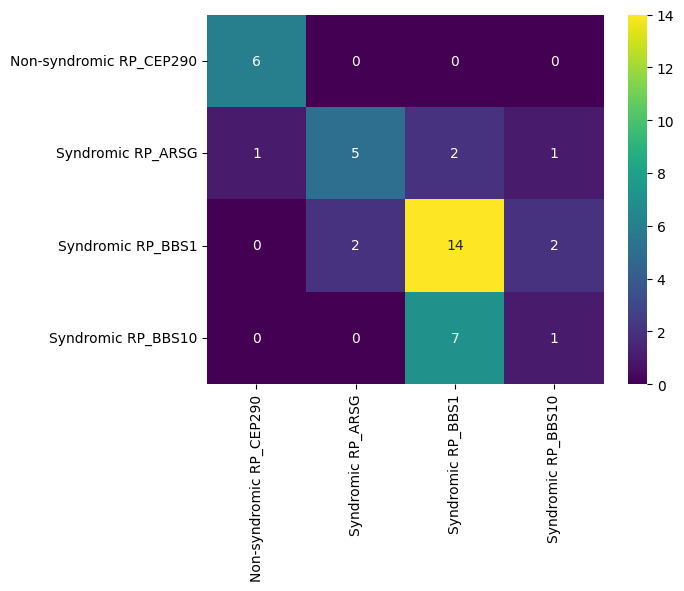

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# ==========================================
# 1. CONFIGURAÇÕES - G4 CONGELAMENTO TOTAL
# ==========================================
DATA_ROOT = '/content/drive/MyDrive/Dataset'
CURRENT_GROUP = 'G4'
TARGET_GENES = [
    'Syndromic RP_BBS1',
    'Syndromic RP_BBS10',
    'Syndromic RP_ARSG',
    'Non-syndromic RP_CEP290'
]

BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 50
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. DATASET
# ==========================================
class RP_Complex_Dataset(Dataset):
    def __init__(self, root_dir, group_name, genes_list, mode='train', transform=None):
        self.transform = transform
        self.image_paths, self.labels = [], []
        self.classes = sorted(genes_list)
        self.class_to_idx = {gene: i for i, gene in enumerate(self.classes)}
        base_folder = 'train_folds' if mode in ['train', 'val'] else 'test_fold'
        group_path = os.path.join(root_dir, base_folder, group_name)

        for gene in genes_list:
            gene_path = os.path.join(group_path, gene)
            if not os.path.exists(gene_path): continue
            label_idx = self.class_to_idx[gene]

            if mode in ['train', 'val']:
                target_nums = ['1', '2', '3', '4'] if mode == 'train' else ['5']
                for folder_name in os.listdir(gene_path):
                    full_fold_path = os.path.join(gene_path, folder_name)
                    if os.path.isdir(full_fold_path) and "fold" in folder_name.lower():
                        if any(num in folder_name for num in target_nums):
                            files = [f for f in os.listdir(full_fold_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                            for f in files:
                                self.image_paths.append(os.path.join(full_fold_path, f))
                                self.labels.append(label_idx)
            else:
                files = [f for f in os.listdir(gene_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                for f in files:
                    self.image_paths.append(os.path.join(gene_path, f))
                    self.labels.append(label_idx)
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# ==========================================
# 3. PREPARAÇÃO (Augmentation Moderado)
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='train', transform=train_tf)
val_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='val', transform=eval_tf)
test_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='test', transform=eval_tf)

counts = np.bincount(train_ds.labels, minlength=len(TARGET_GENES))
weights = torch.tensor([1.0 / c if c > 0 else 0.0 for c in counts], dtype=torch.float).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODELO (CONGELAMENTO TOTAL)
# ==========================================
model = models.resnet50(weights='IMAGENET1K_V1')

# BLOQUEIO: Congelamos todos os parâmetros da rede convolucional
for param in model.parameters():
    param.requires_grad = False

# RECONSTRUÇÃO: Apenas a cabeça (FC) será treinada
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, len(TARGET_GENES))
)
model = model.to(DEVICE)

# IMPORTANTE: Otimizamos apenas os parâmetros da fc
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss(weight=weights)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)

# ==========================================
# 5. TREINO
# ==========================================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience, counter = 12, 0

print(f"\n--- Iniciando Opção A: Congelamento Backbone (G4) ---")
for epoch in range(EPOCHS):
    model.train()
    t_correct, t_total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, pred = torch.max(outputs, 1)
        t_total += labels.size(0); t_correct += (pred == labels).sum().item()

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, pred = torch.max(model(inputs.to(DEVICE)), 1); v_total += labels.size(0); v_correct += (pred == labels.to(DEVICE)).sum().item()

    val_acc = v_correct / v_total
    print(f"Época {epoch+1}/{EPOCHS} | Train Acc: {t_correct/t_total:.4f} | Val Acc: {val_acc:.4f}")
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, f'melhor_modelo_G4_congelado.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"[INFO] Paragem. Modelo estabilizado."); break

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
print("\n--- Relatório Final Opção A (G4) ---")
model.load_state_dict(torch.load(f'melhor_modelo_G4_congelado.pth'))
model.eval(); all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        _, pred = torch.max(model(inputs.to(DEVICE)), 1); all_preds.extend(pred.cpu().numpy()); all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes, labels=range(len(TARGET_GENES)), zero_division=0))
sns.heatmap(confusion_matrix(all_labels, all_preds, labels=range(len(TARGET_GENES))), annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='viridis'); plt.show()

Otimizaçao Grupo 5


--- Iniciando Opção A: Congelamento Backbone (G5) ---
Época 1/50 | Train Acc: 0.3229 | Val Acc: 0.1579
Época 2/50 | Train Acc: 0.3646 | Val Acc: 0.1579
Época 3/50 | Train Acc: 0.4896 | Val Acc: 0.3684
Época 4/50 | Train Acc: 0.5938 | Val Acc: 0.3684
Época 5/50 | Train Acc: 0.7708 | Val Acc: 0.1579
Época 6/50 | Train Acc: 0.6875 | Val Acc: 0.4211
Época 7/50 | Train Acc: 0.8021 | Val Acc: 0.5789
Época 8/50 | Train Acc: 0.8854 | Val Acc: 0.3684
Época 9/50 | Train Acc: 0.8229 | Val Acc: 0.4211
Época 10/50 | Train Acc: 0.8438 | Val Acc: 0.5789
Época 11/50 | Train Acc: 0.8958 | Val Acc: 0.7368
Época 12/50 | Train Acc: 0.8750 | Val Acc: 0.5263
Época 13/50 | Train Acc: 0.9167 | Val Acc: 0.5789
Época 14/50 | Train Acc: 0.8125 | Val Acc: 0.6316
Época 15/50 | Train Acc: 0.9271 | Val Acc: 0.6842
Época 16/50 | Train Acc: 0.9375 | Val Acc: 0.7895
Época 17/50 | Train Acc: 0.9479 | Val Acc: 0.5789
Época 18/50 | Train Acc: 0.9375 | Val Acc: 0.5263
Época 19/50 | Train Acc: 0.9167 | Val Acc: 0.5263
Époc

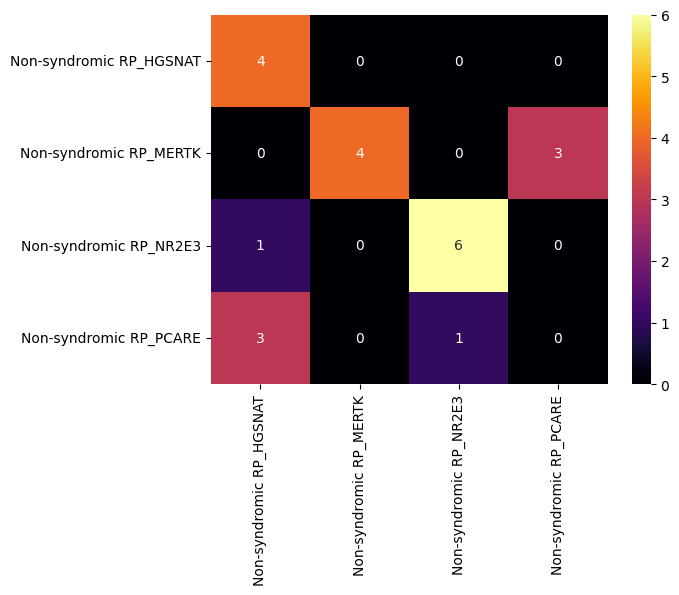

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# ==========================================
# 1. CONFIGURAÇÕES - G5 CONGELAMENTO TOTAL
# ==========================================
DATA_ROOT = '/content/drive/MyDrive/Dataset'
CURRENT_GROUP = 'G5'
TARGET_GENES = [
    'Non-syndromic RP_NR2E3',
    'Non-syndromic RP_PCARE',
    'Non-syndromic RP_MERTK',
    'Non-syndromic RP_HGSNAT'
]

BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 50
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. DATASET
# ==========================================
class RP_Complex_Dataset(Dataset):
    def __init__(self, root_dir, group_name, genes_list, mode='train', transform=None):
        self.transform = transform
        self.image_paths, self.labels = [], []
        self.classes = sorted(genes_list)
        self.class_to_idx = {gene: i for i, gene in enumerate(self.classes)}
        base_folder = 'train_folds' if mode in ['train', 'val'] else 'test_fold'
        group_path = os.path.join(root_dir, base_folder, group_name)

        for gene in genes_list:
            gene_path = os.path.join(group_path, gene)
            if not os.path.exists(gene_path): continue
            label_idx = self.class_to_idx[gene]

            if mode in ['train', 'val']:
                target_nums = ['1', '2', '3', '4'] if mode == 'train' else ['5']
                for folder_name in os.listdir(gene_path):
                    full_fold_path = os.path.join(gene_path, folder_name)
                    if os.path.isdir(full_fold_path) and "fold" in folder_name.lower():
                        if any(num in folder_name for num in target_nums):
                            files = [f for f in os.listdir(full_fold_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                            for f in files:
                                self.image_paths.append(os.path.join(full_fold_path, f))
                                self.labels.append(label_idx)
            else:
                files = [f for f in os.listdir(gene_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                for f in files:
                    self.image_paths.append(os.path.join(gene_path, f))
                    self.labels.append(label_idx)
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# ==========================================
# 3. PREPARAÇÃO (Augmentation Moderado)
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='train', transform=train_tf)
val_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='val', transform=eval_tf)
test_ds = RP_Complex_Dataset(DATA_ROOT, CURRENT_GROUP, TARGET_GENES, mode='test', transform=eval_tf)

counts = np.bincount(train_ds.labels, minlength=len(TARGET_GENES))
weights = torch.tensor([1.0 / c if c > 0 else 0.0 for c in counts], dtype=torch.float).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODELO (CONGELAMENTO TOTAL)
# ==========================================
model = models.resnet50(weights='IMAGENET1K_V1')

# BLOQUEIO: Congelamos todos os parâmetros pré-treinados
for param in model.parameters():
    param.requires_grad = False

# RECONSTRUÇÃO: Apenas a cabeça final será treinável
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, len(TARGET_GENES))
)
model = model.to(DEVICE)

# Otimizamos apenas os pesos da fc
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss(weight=weights)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)

# ==========================================
# 5. TREINO
# ==========================================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience, counter = 12, 0

print(f"\n--- Iniciando Opção A: Congelamento Backbone (G5) ---")
for epoch in range(EPOCHS):
    model.train()
    t_correct, t_total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, pred = torch.max(outputs, 1)
        t_total += labels.size(0); t_correct += (pred == labels).sum().item()

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, pred = torch.max(model(inputs.to(DEVICE)), 1); v_total += labels.size(0); v_correct += (pred == labels.to(DEVICE)).sum().item()

    val_acc = v_correct / v_total
    print(f"Época {epoch+1}/{EPOCHS} | Train Acc: {t_correct/t_total:.4f} | Val Acc: {val_acc:.4f}")
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, f'melhor_modelo_G5_congelado.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"[INFO] Paragem. Modelo estabilizado."); break

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
print("\n--- Relatório Final Opção A (G5) ---")
model.load_state_dict(torch.load(f'melhor_modelo_G5_congelado.pth'))
model.eval(); all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        _, pred = torch.max(model(inputs.to(DEVICE)), 1); all_preds.extend(pred.cpu().numpy()); all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes, labels=range(len(TARGET_GENES)), zero_division=0))
sns.heatmap(confusion_matrix(all_labels, all_preds, labels=range(len(TARGET_GENES))), annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='inferno'); plt.show()